# Imports

In [1]:
from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import os  # add directory containing the input data (opacity, abundance and stellar specs files)
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

import h5py

import numpy as np
import matplotlib.pyplot as plt

import starships.retrieval_utils as ru

# Quicklook at one of the files

In [19]:
# Path to the walker files
planet = "TRAPPIST-1b"
walker_path = Path(f'/home/mathisb/scratch/HRS_retrievals/walker_steps/{planet}/')

In [20]:
ls -t1 $walker_path | head -15  # list the walker files

walker_steps_H2atm_CH4_3n.h5
walker_steps_H2_multiple.h5
walker_steps_H2atm_H2O_3n_1.h5
walker_steps_H2atm_H2O_3n_5.h5
walker_steps_H2atm_CO2_3n_8.h5
walker_steps_H2atm_CO2.h5
walker_steps_H2atm_CO2_3n_7.h5
walker_steps_H2atm_CO2_3n_10.h5
walker_steps_H2atm_CO2_3n_5.h5
walker_steps_H2atm_H2O_3n_4.h5
walker_steps_H2atm_H2O_3n_3.h5
walker_steps_H2atm_H2O_3n_7.h5
walker_steps_H2atm_CO2_3n_6.h5
walker_steps_H2atm_H2O_3n_2.h5
walker_steps_H2atm_CO2_3n_3.h5
ls: write error: Broken pipe


In [36]:
# Choose which walker files to look at and merge (copy-paste one of them)
walkers_to_merge = 'walker_steps_H2atm_H2O_3n_7.h5'

INFO:starships.retrieval_utils:Steps in walkers file are all completed


0: Maximum=-7.006939321445987, Error=[-4.70124712  3.38725778], HDI(68.00%)=[-11.70818644  -3.61968154]
1: Maximum=-7.787475732281181, Error=[-2.95505715  1.58255145], HDI(68.00%)=[-10.74253288  -6.20492428]


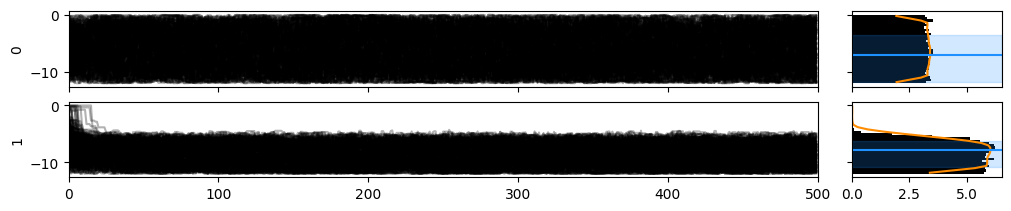

In [37]:
walker_file = Path(walkers_to_merge)
chains = ru.read_walkers_file(walker_path / walker_file, discard=0)
maxs, errors = ru.find_dist_maxs(chains, bin_size=6)

# Merge multiple walker files

In [38]:
# Get a list of walker files from the same run as walkers_to_merge
walker_file_list = [f for f in walker_path.glob(walkers_to_merge[:-4] + '*.h5')
                    if 'combined' not in f.name]  # exclude combined walker file if this notebook has already been run

# Name for combined file
combined_file_out = Path(walkers_to_merge[:-4] + 'combined.h5')

## Get number of steps (minimum among all files)

In [39]:
# The different walker files might not have run for the same number of steps,
# so here we calculate the minimum number of steps all files have run through

nsteps = 5000  # upper limit to number of steps to use

for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file, 'r') as f:
        dset = f['mcmc']
        print(walker_file, 'n_steps:', dset.attrs['iteration'])
        nsteps = np.min([nsteps, dset.attrs['iteration']])

nsteps = int(nsteps)
print('nsteps:', nsteps)

/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_10.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_9.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_8.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_1.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_2.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_3.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_7.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_6.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_H2atm_H2O_3n_4.h5 n_steps: 500
/home/mathisb/scratch/HRS_retrievals/walker_s

## Show best walkers from all files

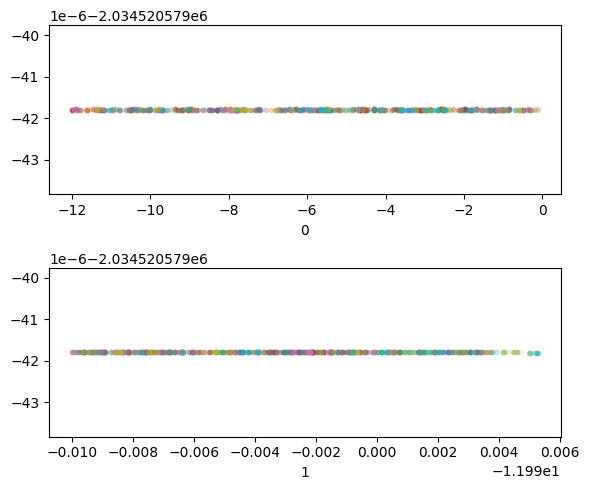

In [40]:

n_best = 200  # number of highest-likelihood samples to visualize

fig = None

for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file) as f:
        dset = f['mcmc']

        # Extract the last nsteps of the chains and likelihoods, flatten all walkers
        # into a single sample list, then sort samples by increasing log-likelihood.
        ord_logl = dset['log_prob'][-nsteps:].reshape(-1)
        
        ord_pos = dset['chain'][-nsteps:]
        n_param = ord_pos.shape[-1]
        ord_pos = ord_pos.reshape((-1, n_param))
        
        idx_sort = np.argsort(ord_logl)
        ord_pos = ord_pos[idx_sort]
        ord_logl = ord_logl[idx_sort]


        if fig is None:
            fig, ax = plt.subplots(n_param, 1, figsize=(6, 2.5*n_param))
        
        for i_param, ax_i in enumerate(ax):
            # Plot parameter value vs log-likelihood
            # Only keep the top n_best (highest likelihood) samples
            ax_i.plot(
                ord_pos[-n_best:, i_param],    # parameter values
                ord_logl[-n_best:],            # corresponding log-likelihoods
                ".", alpha=0.1               
            )
            # ax_i.set_ylim(*ylim)
            ax_i.set_xlabel(i_param)

plt.tight_layout()
        

## Combine the different files

In [41]:
combined = {key: [] for key in ['accepted', 'chain', 'log_prob']}  # initialize containers

for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file) as f:
        dset = f['mcmc']
        last_step = dset.attrs['iteration']  # total steps in this file

        for key in ['chain', 'log_prob']:
            # keep ONLY the last nsteps
            combined[key].append(dset[key][last_step - nsteps: last_step])

        # keep all acceptance info (not sliced)
        combined['accepted'].append(dset['accepted'][...])

# concatenate across files
combined['chain'] = np.concatenate(combined['chain'], axis=1)     # stack walkers
combined['log_prob'] = np.concatenate(combined['log_prob'], axis=1)
combined['accepted'] = np.concatenate(combined['accepted'])

In [42]:
print("Name of combined walker file:", combined_file_out)

print(f"\n{combined['chain'].shape} <-- should be (nsteps, nwalkers_total, nparams)")
print(combined['log_prob'].shape)

print("\nReminder: nwalkers_total = nfiles_in_parallel * cpus-per-task * n_walkers_per_cpu")

Name of combined walker file: walker_steps_H2atm_H2O_3n_combined.h5

(500, 2000, 2) <-- should be (nsteps, nwalkers_total, nparams)
(500, 2000)

Reminder: nwalkers_total = nfiles_in_parallel * cpus-per-task * n_walkers_per_cpu


## And save

In [43]:
with h5py.File(walker_path / combined_file_out, 'a') as f:
    grp = f.create_group("mcmc")
    for key, val in combined.items():
        grp[key] = val
        
    grp.attrs['has_blob'] = False
    for key, val in zip(['iteration', 'nwalkers', 'ndim'], combined['chain'].shape):
        grp.attrs[key] = val
    

## Read the saved file to check if all went well

In [44]:
with h5py.File(walker_path / combined_file_out) as f:
    dset = f['mcmc']
    print(list(dset))
    print(dset['accepted'])
    print(dset['chain'])
    print(dset['log_prob'])
    print(dset.attrs['iteration'])


['accepted', 'chain', 'log_prob']
<HDF5 dataset "accepted": shape (2000,), type "<f8">
<HDF5 dataset "chain": shape (500, 2000, 2), type "<f8">
<HDF5 dataset "log_prob": shape (500, 2000), type "<f8">
500


In [45]:
chains = ru.read_walkers_file(walker_path / combined_file_out, discard=0)

INFO:starships.retrieval_utils:Steps in walkers file are all completed


In [46]:
# maxs, errors = ru.find_dist_maxs(chains, bin_size=6)

## Check what the initialisation would look like

In [48]:
# Initialize the walkers
# The first argument is n_walkers = n_walkers_per_cpu * n_cpu
pos_init, logl_init = ru.init_from_burnin(200, wlkr_file=combined_file_out, wlkr_path=walker_path, n_best_min=10000)

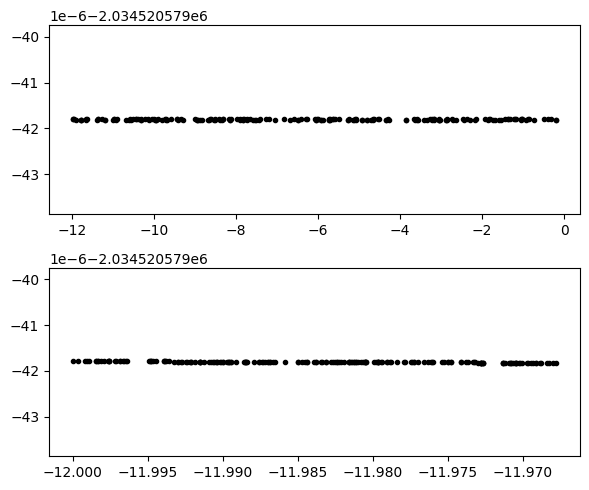

In [49]:
fig, ax = plt.subplots(pos_init.shape[-1], 1, figsize=(6, 2.5*pos_init.shape[-1]))
# ymin, ymax = (np.quantile(logl_init, 0.5), np.max(logl_init))
# dy = ymax - ymin
# ylim = (ymin - 0.1 * dy, ymax + 0.1 * dy)
for i_param, ax_i in enumerate(ax):
    ax_i.plot(pos_init[:,i_param], logl_init[:], ".k", )
#     ax_i.set_ylim(*ylim)
#     ax_i.set_xlabel(i_param)
#     ax_i.axhline(23374, linestyle=":")
plt.tight_layout()

In [50]:
output = ru.read_walker_prob(walker_path/combined_file_out, tol=8, discard=0)
ord_pos = output[0]
ord_logl = output[1]

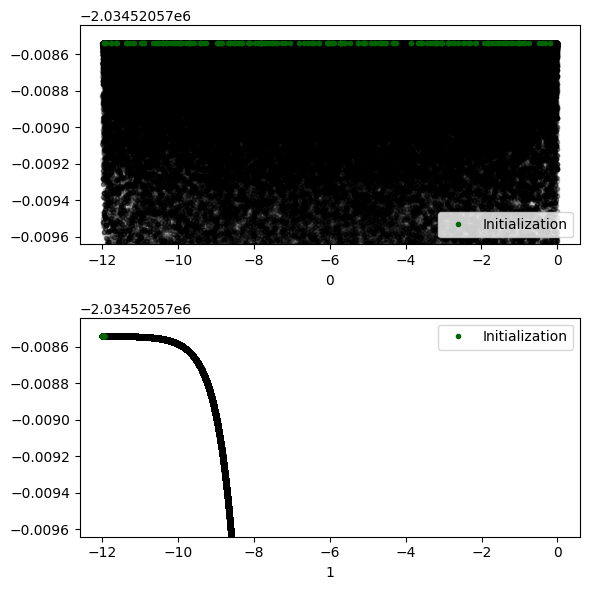

In [51]:
fig, ax = plt.subplots(ord_pos.shape[-1], 1, figsize=(6, 3*ord_pos.shape[-1]))
ymin, ymax = (np.quantile(ord_logl, 0.5), np.max(ord_logl))
dy = ymax - ymin
ylim = (ymin - 0.1 * dy, ymax + 0.1 * dy)
for i_param, ax_i in enumerate(ax):
    ax_i.plot(ord_pos[:,i_param], ord_logl[:], ".k", alpha=0.1)
    ax_i.plot(pos_init[:,i_param], logl_init, ".", color='darkgreen', label='Initialization')
    ax_i.set_ylim(*ylim)
    ax_i.set_xlabel(i_param)
    ax_i.legend()
plt.tight_layout()